In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

with open("../data/curated_papers_text.json", "r", encoding="utf-8") as file:
    data = json.load(file)

print("Dataset loaded successfully.")
print("Number of papers:", len(data))

Matplotlib is building the font cache; this may take a moment.


Dataset loaded successfully.
Number of papers: 10


In [2]:
paper_summary = []

for paper in data:
    paper_summary.append({
        "ID": paper["id"],
        "Title": paper["title"],
        "Category": paper["category"],
        "Total Pages": paper["total_pages"]
    })

df_papers = pd.DataFrame(paper_summary)

df_papers

,ID,Title,Category,Total Pages
0,2005.11401,Retrieval-Augmented Generation for Knowledge-I...,RAG,19
1,2312.10997,Retrieval-Augmented Generation for Large Langu...,RAG Survey,21
2,2310.11511,"Self-RAG: Learning to Retrieve, Generate, and ...",Self-Correction,30
3,2401.15884,Corrective Retrieval Augmented Generation (CRAG),Corrective RAG,16
4,2210.03629,ReAct: Synergizing Reasoning and Acting in Lan...,Agent Reasoning,33
5,2307.03172,Lost in the Middle: How Language Models Use Lo...,Context Windows,18
6,2309.15217,RAGAS: Automated Evaluation of Retrieval Augme...,Evaluation,8
7,2106.09685,LoRA: Low-Rank Adaptation of Large Language Mo...,Model Architecture,26
8,2205.14135,FlashAttention: Fast and Memory-Efficient Exac...,Systems,34
9,2004.04906,Dense Passage Retrieval for Open-Domain Questi...,Embeddings,13


In [3]:
print("Number of papers:", len(df_papers))
print("Total pages:", df_papers["Total Pages"].sum())
print("Average pages per paper:", round(df_papers["Total Pages"].mean(), 2))
print("Minimum pages:", df_papers["Total Pages"].min())
print("Maximum pages:", df_papers["Total Pages"].max())

print("\nPapers by category:")
print(df_papers["Category"].value_counts())

Number of papers: 10
Total pages: 218
Average pages per paper: 21.8
Minimum pages: 8
Maximum pages: 34

Papers by category:
Category
RAG                   1
RAG Survey            1
Self-Correction       1
Corrective RAG        1
Agent Reasoning       1
Context Windows       1
Evaluation            1
Model Architecture    1
Systems               1
Embeddings            1
Name: count, dtype: int64


In [4]:
page_records = []

for paper in data:
    for page in paper["pages"]:
        text = page.get("text", "")

        page_records.append({
            "Paper ID": paper["id"],
            "Title": paper["title"],
            "Category": paper["category"],
            "Page Number": page["page_number"],
            "Text Length": len(text),
            "Word Count": len(text.split()),
            "Is Empty": len(text.strip()) == 0
        })

df_pages = pd.DataFrame(page_records)

print("Total extracted pages:", len(df_pages))
print("Empty pages:", df_pages["Is Empty"].sum())
print("Average words per page:", round(df_pages["Word Count"].mean(), 2))
print("Minimum words on a page:", df_pages["Word Count"].min())
print("Maximum words on a page:", df_pages["Word Count"].max())

df_pages.head()

Total extracted pages: 218
Empty pages: 0
Average words per page: 557.69
Minimum words on a page: 79
Maximum words on a page: 1354


,Paper ID,Title,Category,Page Number,Text Length,Word Count,Is Empty
0,2005.11401,Retrieval-Augmented Generation for Knowledge-I...,RAG,1,2898,401,False
1,2005.11401,Retrieval-Augmented Generation for Knowledge-I...,RAG,2,4547,645,False
2,2005.11401,Retrieval-Augmented Generation for Knowledge-I...,RAG,3,3656,549,False
3,2005.11401,Retrieval-Augmented Generation for Knowledge-I...,RAG,4,4205,659,False
4,2005.11401,Retrieval-Augmented Generation for Knowledge-I...,RAG,5,4556,698,False


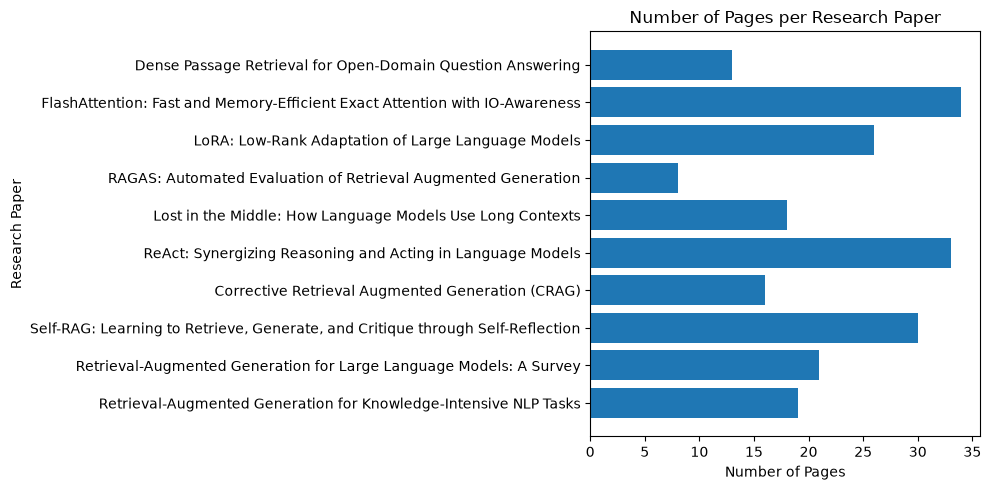

In [5]:
plt.figure(figsize=(10, 5))

plt.barh(df_papers["Title"], df_papers["Total Pages"])

plt.xlabel("Number of Pages")
plt.ylabel("Research Paper")
plt.title("Number of Pages per Research Paper")

plt.tight_layout()
plt.show()

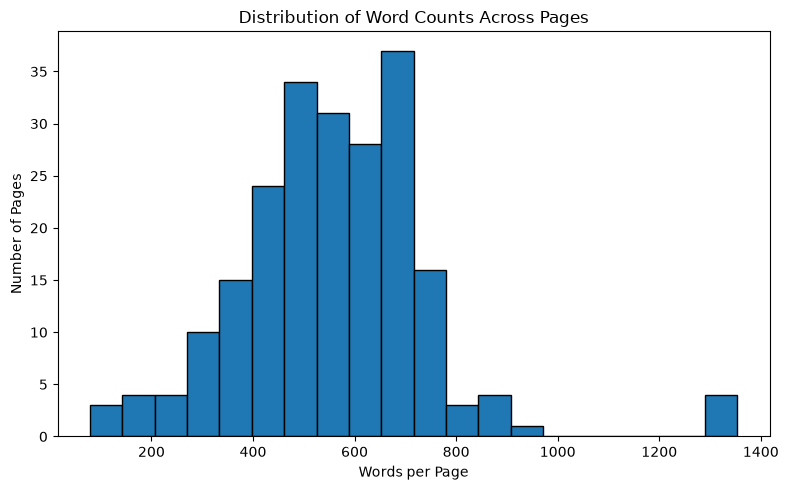

In [6]:
plt.figure(figsize=(8, 5))

plt.hist(df_pages["Word Count"], bins=20, edgecolor="black")

plt.xlabel("Words per Page")
plt.ylabel("Number of Pages")
plt.title("Distribution of Word Counts Across Pages")

plt.tight_layout()
plt.show()

In [7]:
quality_checks = {
    "Empty pages": (df_pages["Word Count"] == 0).sum(),
    "Very short pages (< 100 words)": (df_pages["Word Count"] < 100).sum(),
    "Very long pages (> 1000 words)": (df_pages["Word Count"] > 1000).sum()
}

for check, count in quality_checks.items():
    print(f"{check}: {count}")

Empty pages: 0
Very short pages (< 100 words): 1
Very long pages (> 1000 words): 4


In [8]:
unusual_pages = df_pages[
    (df_pages["Word Count"] < 100) |
    (df_pages["Word Count"] > 1000)
][["Title", "Page Number", "Word Count", "Text Length"]]

unusual_pages

,Title,Page Number,Word Count,Text Length
35,Retrieval-Augmented Generation for Large Langu...,17,1341,8574
36,Retrieval-Augmented Generation for Large Langu...,18,1354,9049
37,Retrieval-Augmented Generation for Large Langu...,19,1339,8906
38,Retrieval-Augmented Generation for Large Langu...,20,1329,9110
39,Retrieval-Augmented Generation for Large Langu...,21,79,519


In [9]:
for index, row in unusual_pages.iterrows():
    matching_page = next(
        page
        for paper in data
        if paper["title"] == row["Title"]
        for page in paper["pages"]
        if page["page_number"] == row["Page Number"]
    )

    print("=" * 80)
    print("Paper:", row["Title"])
    print("Page:", row["Page Number"])
    print("Word Count:", row["Word Count"])
    print("\nText Preview:")
    print(matching_page["text"][:500])
    print()

Paper: Retrieval-Augmented Generation for Large Language Models: A Survey
Page: 17
Word Count: 1341

Text Preview:
17
The growing ecosystem of RAG is evidenced by the rise in
RAG-centric AI applications and the continuous development
of supportive tools. As RAG’s application landscape broadens,
there is a need to refine evaluation methodologies to keep
pace with its evolution. Ensuring accurate and representative
performance assessments is crucial for fully capturing RAG’s
contributions to the AI research and development community.
REFERENCES
[1] N. Kandpal, H. Deng, A. Roberts, E. Wallace, and C. Raffel, “L

Paper: Retrieval-Augmented Generation for Large Language Models: A Survey
Page: 18
Word Count: 1354

Text Preview:
18
[44] B. Wang, W. Ping, P. Xu, L. McAfee, Z. Liu, M. Shoeybi, Y . Dong,
O. Kuchaiev, B. Li, C. Xiao et al. , “Shall we pretrain autoregressive
language models with retrieval? a comprehensive study,”arXiv preprint
arXiv:2304.06762, 2023.
[45] B. Wang, W. Ping, L. McA

## Additional EDA: Document and Page-Length Analysis

This analysis examines document length and page-level word-count distributions across the research paper dataset.

### Key Findings

- The dataset contains 10 research papers and 218 extracted pages.
- Papers average 21.8 pages and range from 8 to 34 pages.
- Pages contain approximately 558 words on average.
- Most pages contain roughly 400–750 words.
- No empty pages were identified.
- One page contains fewer than 100 words.
- Four pages contain more than 1,000 words.
- All five word-count outliers occur in the *Retrieval-Augmented Generation for Large Language Models: A Survey* paper.
- Inspection of these outliers indicates that the unusually long pages primarily contain references rather than corrupted or missing data.

### Implications for RAG Preprocessing

Page lengths vary considerably across the dataset, so page boundaries should not automatically be treated as retrieval chunks. Reference-heavy sections may also introduce noise into semantic retrieval. During preprocessing and chunking, document metadata such as paper ID, title, category, and page number should be preserved to support accurate retrieval and citations.